In [1]:
import os

# Walk through the input directory to see the subfolders
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    # This prevents printing thousands of individual image file names
    if len(filenames) > 0:
        print(f"-> Found {len(filenames)} images in this folder.")
        break

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/emmarex
/kaggle/input/datasets/emmarex/plantdisease
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot
-> Found 997 images in this folder.


In [2]:
import os
# Suppress TensorFlow logging (0 = all logs, 1 = filter INFO, 2 = filter WARNING, 3 = filter ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import tensorflow as tf

# 1. Update this path to match Kaggle's filesystem
DATASET_PATH = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 10

# 2. Create the Training dataset (70%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# 3. Create the temporary dataset for splitting (30%)
temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# 4. Split the 30% into 15% Validation and 15% Test
temp_batches = tf.data.experimental.cardinality(temp_ds)
val_ds = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)

NUM_CLASSES = 15

# 5. Optimize performance with Autotune Prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# 6. Your pre-calculated class weights for handling data imbalance
class_weights = {
    0: 1.3858033573141486, 1: 0.9451750081779522, 2: 1.347039627039627,
    3: 1.347039627039627, 4: 9.631333333333334, 5: 0.6534147444595205,
    6: 1.358439116125999, 7: 0.7050756466569058, 8: 1.4311045071817732,
    9: 0.7907498631636563, 10: 0.8288582903040734, 11: 0.9451750081779522,
    12: 0.4278690952169406, 13: 3.821957671957672, 14: 0.8926166203274637
}

print("\nData pipeline successfully initialized on Kaggle!")

E0000 00:00:1782474427.699456      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782474427.764206      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782474428.290598      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782474428.290660      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782474428.290663      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782474428.290666      58 computation_placer.cc:177] computation placer already registered. Please check linka

Found 20638 files belonging to 15 classes.
Using 14447 files for training.


I0000 00:00:1782474455.050813      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782474455.057047      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20638 files belonging to 15 classes.
Using 6191 files for validation.

Data pipeline successfully initialized on Kaggle!


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print('Mixed Precision Enabled')


Mixed Precision Enabled


In [4]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [5]:
data_augmentation=tf.keras.Sequential([layers.RandomFlip('horizontal'),layers.RandomRotation(0.1),layers.RandomZoom(0.1)])
base_model=EfficientNetB0(include_top=False,weights='imagenet',input_shape=(224,224,3))

base_model.trainable=False
print('trainable layers',len(base_model.trainable_variables))

inputs=tf.keras.Input(shape=(224,224,3))
x=data_augmentation(inputs)
x=tf.keras.applications.efficientnet.preprocess_input(x)
x=base_model(x,training=False)
x=layers.GlobalAveragePooling2D()(x)
x=layers.BatchNormalization()(x)

x=layers.Dense(256,activation='relu')(x)
x=layers.Dropout(0.3)(x)
outputs=layers.Dense(NUM_CLASSES,activation='softmax',dtype='float32')(x)
model=Model(inputs,outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
trainable layers 0


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,386,482 (16.73 MB)

 Trainable params: 334,351 (1.28 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [6]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
checkpoint=tf.keras.callbacks.ModelCheckpoint('best_efficientnet_frozen.keras',save_best_only=True,monitor='val_loss')

history=model.fit(train_ds,validation_data=val_ds,epochs=15,class_weight=class_weights,callbacks=[early_stop,checkpoint])
test_loss,test_acc=model.evaluate(test_ds)

Epoch 1/15


I0000 00:00:1782474476.596627     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


452/452 ━━━━━━━━━━━━━━━━━━━━ 90s 124ms/step - accuracy: 0.7957 - loss: 0.6515 - val_accuracy: 0.8837 - val_loss: 0.3388
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 36s 80ms/step - accuracy: 0.8889 - loss: 0.3382 - val_accuracy: 0.9059 - val_loss: 0.2857
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.9057 - loss: 0.2723 - val_accuracy: 0.9265 - val_loss: 0.2144
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.9109 - loss: 0.2493 - val_accuracy: 0.9385 - val_loss: 0.1939
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 36s 81ms/step - accuracy: 0.9260 - loss: 0.2332 - val_accuracy: 0.9365 - val_loss: 0.2010
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.9239 - loss: 0.2386 - val_accuracy: 0.9443 - val_loss: 0.1760
Epoch 7/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.9309 - loss: 0.2109 - val_accuracy: 0.9465 - val_loss: 0.1634
Epoch 8/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 36s 81ms/step - accuracy: 0.9401 - loss: 0.1794 - val_accura

In [9]:
print("Test Accuracy : ",test_acc)
y_true=[]
y_pred=[]
for images,labels in test_ds:
  preds=model.predict(images,verbose=0)
  preds=np.argmax(preds,axis=1)
  y_true.extend(labels.numpy())
  y_pred.extend(preds)

  accuracy=accuracy_score(y_true,y_pred)
  precision=precision_score(y_true,y_pred,average='weighted')
  recall=recall_score(y_true,y_pred,average='weighted')
  f1=f1_score(y_true,y_pred,average='weighted')

# If train_ds is a PrefetchDataset, we pull class_names from the underlying raw dataset
if hasattr(train_ds, 'class_names'):
    class_names = train_ds.class_names
else:
    # Fallback: tf.data structures store the original dataset inside '_input_dataset'
    class_names = train_ds._input_dataset.class_names

# Run your metrics code right after this...

print(classification_report(y_true,y_pred,target_names=class_names))

print("\n accuracy",accuracy)
print('precision : ',precision)
print("recall :",recall)
print('f1 : ',f1)

Test Accuracy :  0.9643666744232178
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      1.00      0.99       147
                     Pepper__bell___healthy       0.99      0.99      0.99       226
                      Potato___Early_blight       0.96      1.00      0.98       136
                       Potato___Late_blight       0.98      0.98      0.98       129
                           Potato___healthy       0.96      0.96      0.96        23
                      Tomato_Bacterial_spot       0.99      0.96      0.98       341
                        Tomato_Early_blight       0.93      0.88      0.91       147
                         Tomato_Late_blight       0.95      0.98      0.97       275
                           Tomato_Leaf_Mold       0.98      0.95      0.97       138
                  Tomato_Septoria_leaf_spot       0.95      0.93      0.94       278
Tomato_Spider_mites_Two_spot

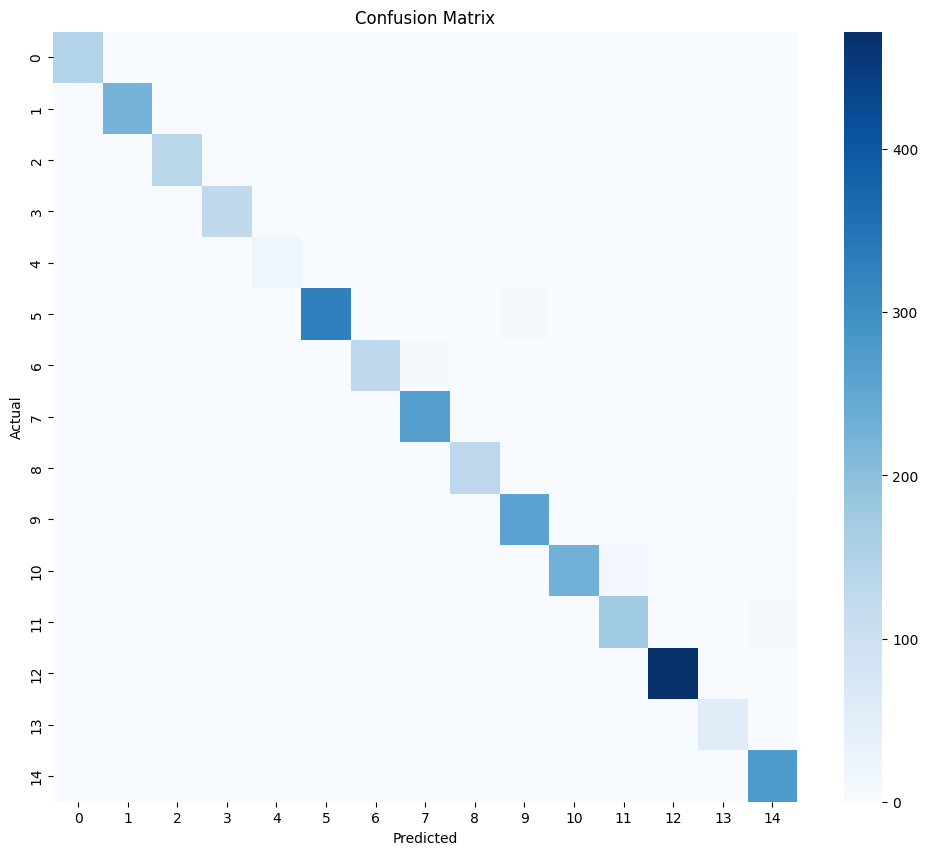

In [10]:
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm,cmap='Blues',annot=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

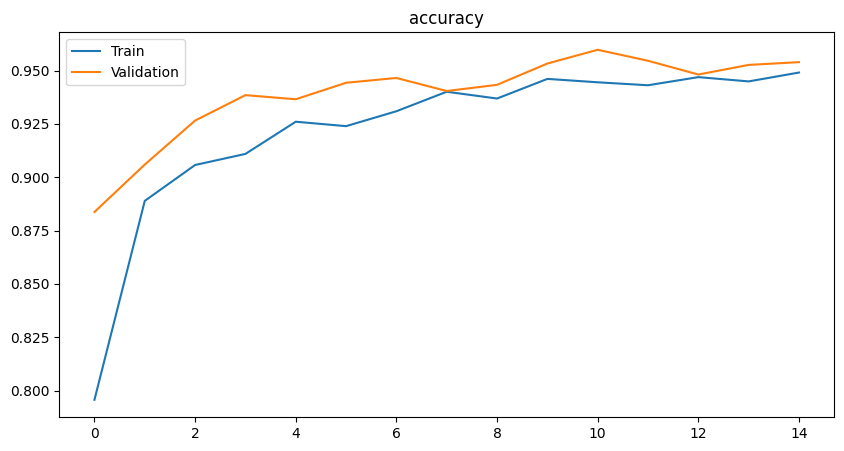

In [11]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.title('accuracy')
plt.legend()
plt.show()

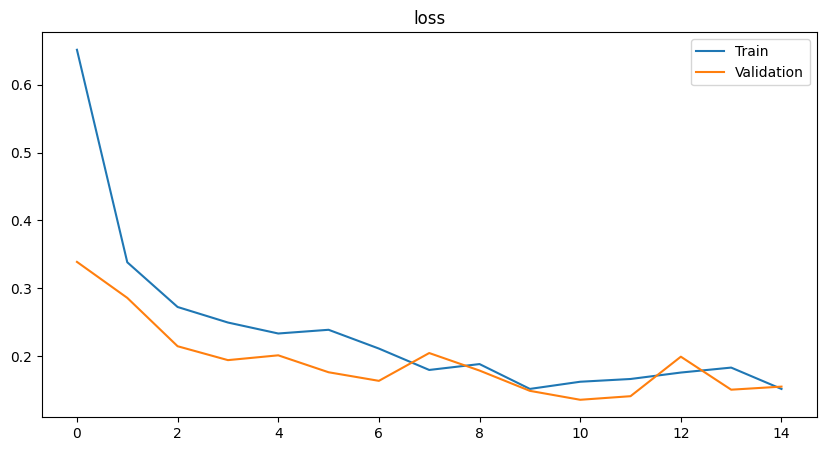

model saved


In [12]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label="Validation")
plt.title('loss')
plt.legend()
plt.show()

model.save('plant_diseaseEfficient.keras')
print('model saved')

In [13]:
from IPython.display import FileLink

# This creates a clickable download link right in your notebook cell
FileLink(r'plant_diseaseEfficient.keras')

/kaggle/working/plant_diseaseEfficient.keras